In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prep

In [203]:
transect = pd.read_csv('../../../data/Transect.csv')
ssdf = pd.read_csv('../../../data/SCDs.csv')

In [204]:
ssdf

,Stop,Name,Description,Long,Lat,No Measurements,Res 1,Res 2,Res 3,Res 4,...,Res 9,Res 10,Res 11,Res 12,Res 13,Res 14,Res 15,Average,Max,Max>20
0,6,SomSCD-1a,GolfCourse1,51 01 31 N,03 12 07 W,15.0,21,23,4,5,...,22.0,82.0,5.0,15.0,37.0,49.0,16.0,25.666667,106,True
1,7,SomSCD-2a,NoVegHalse,51 02 05 N,03 12 40 W,5.0,2,4,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.200000,20,True
2,7,SomSCD-2b,VegHalse,-,-,15.0,30,23,19,7,...,14.0,28.0,5.0,31.0,16.0,51.0,48.0,21.066667,51,True
3,8,SomSCD-3a,LargeFieldBig,51 03 53 N,03 09 60 W,4.0,2,2,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.500000,2,False
4,8,SomSCD-3b,LargeFieldCar,-,-,4.0,0,2,4,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.750000,9,False
5,9,SomSCD-3c,Oval,51 04 24 N,03 10 38 W,5.0,5,6,4,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.400000,8,False
6,10,SomSCD-4a,Pylon,51 06 45 N,03 03 11 W,6.0,5,4,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.666667,5,False
7,10,SomSCD-4b,Pylon,-,-,4.0,1,4,2,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,5,False
8,11,SomSCD-5a,NorthRes,NaN,NaN,7.0,23,5,10,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,23,True
9,11,SomSCD-5b,NorthRes,NaN,NaN,5.0,14,0,0,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.600000,14,False


In [205]:
ssdf.columns

Index(['Stop', 'Name', 'Description', 'Long', 'Lat', 'No Measurements',
       'Res 1', 'Res 2', 'Res 3', 'Res 4', 'Res 5', 'Res 6', 'Res 7', 'Res 8',
       'Res 9', 'Res 10', 'Res 11', 'Res 12', 'Res 13', 'Res 14', 'Res 15',
       'Average', 'Max', 'Max>20'],
      dtype='str')

In [206]:
ssdf[['Res 1', 'Res 2', 'Res 3', 'Res 4', 'Res 5', 'Res 6', 'Res 7', 'Res 8',
       'Res 9', 'Res 10', 'Res 11', 'Res 12', 'Res 13', 'Res 14', 'Res 15']]

,Res 1,Res 2,Res 3,Res 4,Res 5,Res 6,Res 7,Res 8,Res 9,Res 10,Res 11,Res 12,Res 13,Res 14,Res 15
0,21,23,4,5,15.0,20.0,39.0,32.0,22.0,82.0,5.0,15.0,37.0,49.0,16.0
1,2,4,5,5,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,30,23,19,7,23.0,14.0,5.0,2.0,14.0,28.0,5.0,31.0,16.0,51.0,48.0
3,2,2,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,2,4,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,6,4,4,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,5,4,1,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1,4,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,23,5,10,3,4.0,15.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,14,0,0,3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Overall Stats:

In [207]:
transect['mean'] = transect[['Res 1', 'Res 2', 'Res 3 ', 'Res 4', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']].mean(axis=1)

In [208]:
sampled_sites = len(transect) + len(ssdf)
print(f'Total sampled sites: {sampled_sites}')
print(len(transect), 'transect sites')

Total sampled sites: 49
34 transect sites


In [209]:
transect_median = transect['mean'].median(axis=0)
print(f'Transect median: {transect_median}')

Transect median: 4.75


Localities above background:

In [210]:
background_level = 9
print(f'Localities above background: {len(ssdf[ssdf["Average"] > background_level]) + len(transect[transect[["Res 1", "Res 2", "Res 3 ", "Res 4"]].mean(axis=1) > background_level])}')

Localities above background: 15


# Background Threshold

## Using Mean

already calculated then lost the df i used :()

In [211]:
if False:
    # median absolute deviation
    # calculating background level using median absolute deviation (MAD)

    mad = (df['mean'] - df['mean'].median()).abs().median()
    print(f'Median Absolute Deviation: {mad}')

    median = df['mean'].median()
    print(f'Median: {median}')

    background_level = median + 2 * mad
    print(f'Background Level: {background_level}')


## Using max

In [212]:
if False:
    # median absolute deviation
    # calculating background level using median absolute deviation (MAD)

    mad = (df['H2Max'] - df['H2Max'].median()).abs().median()
    print(f'Median Absolute Deviation: {mad}')

    median = df['H2Max'].median()
    print(f'Median: {median}')

    max_background_level = median + 2 * mad
    print(f'Background Level: {max_background_level}')

# SCDs above background

## Using Mean

In [213]:
ssdf = pd.read_csv('../../../data/SCDs.csv')
ssdf['log_mean'] = np.log10(ssdf['Average'])
ssdf['log_max'] = np.log10(ssdf['Max'])

In [214]:
print(f'Num SCDs above background level: {ssdf[ssdf["Average"] > 9].shape[0]}')

Num SCDs above background level: 7


# Max and Mean population histograms

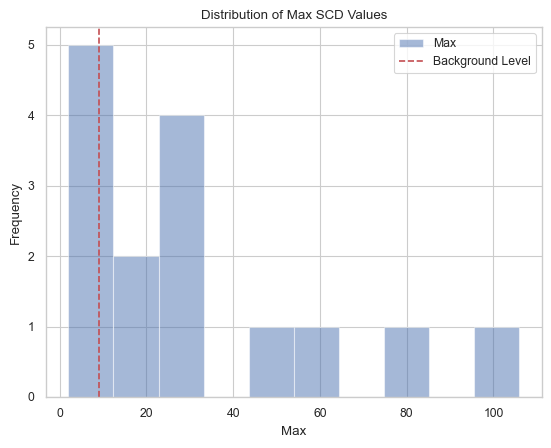

In [215]:
plt.hist(ssdf['Max'], bins=10, alpha=0.5, label='Max')
plt.axvline(9, color='r', linestyle='dashed',  label='Background Level')   
plt.xlabel('Max')
plt.ylabel('Frequency')
plt.title('Distribution of Max SCD Values')
plt.legend()
plt.show()

# SCD vs Non-SCD populations

Yes: n=15, median=23.000, mean=30.267
No:  n=33, median=10.000, mean=13.333

Mann-Whitney U: U=343.0, p=0.0342
Welch's t-test: t=2.117, p=0.0500


/var/folders/fx/yls4l5xd4cdgs4b7gy2xpdv40000gn/T/ipykernel_33668/3234758984.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([no_vals, yes_vals], labels=['No', 'Yes'])


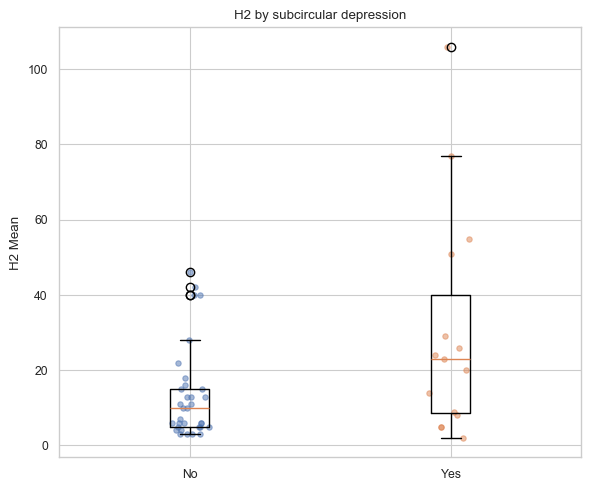

In [216]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

cols = ['Res 1', 'Res 2', 'Res 3 ', 'Res 4', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']
yes_vals = ssdf['Max']
no_vals = pd.read_csv('../../../data/Transect.csv')[cols].max(axis=1)

no_vals = no_vals[no_vals < 100]
print(f"Yes: n={len(yes_vals)}, median={yes_vals.median():.3f}, mean={yes_vals.mean():.3f}")
print(f"No:  n={len(no_vals)}, median={no_vals.median():.3f}, mean={no_vals.mean():.3f}")

u_stat, u_p = stats.mannwhitneyu(yes_vals, no_vals, alternative='two-sided')
t_stat, t_p = stats.ttest_ind(yes_vals, no_vals, equal_var=False)

print(f"\nMann-Whitney U: U={u_stat:.1f}, p={u_p:.4f}")
print(f"Welch's t-test: t={t_stat:.3f}, p={t_p:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([no_vals, yes_vals], labels=['No', 'Yes'])
ax.scatter(np.random.normal(1, 0.04, len(no_vals)), no_vals, alpha=0.5, s=15)
ax.scatter(np.random.normal(2, 0.04, len(yes_vals)), yes_vals, alpha=0.5, s=15)
ax.set_ylabel('H2 Mean')
ax.set_title('H2 by subcircular depression')
plt.tight_layout()
plt.show()

In [217]:
# mean and standard deviation of all values

transect2 = pd.read_csv('../../../data/Transect.csv')
ssdf2 = pd.read_csv('../../../data/SCDs.csv')

t_flat = transect2[['Res 1', 'Res 2', 'Res 3 ', 'Res 4', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']].values.flatten()
t_vals = t_flat[~np.isnan(t_flat)]
res_cols = [f'Res {i}' for i in range(1, 16)]
flat_vals = ssdf2[res_cols].values.flatten()
scd_vals = flat_vals[~np.isnan(flat_vals)]


In [218]:
all_points = np.concatenate((t_vals, scd_vals))

Replace 200 ppm value with 300 ppm (as per lab analysis)

In [219]:
all_points[all_points == 200] = 300

In [220]:
all_points

array([  3.,   3.,   3.,   3.,   5.,  46.,  41.,  22.,   2.,   2.,   1.,
        40.,   4.,   5.,  13.,   9.,   1.,   3.,   1.,   2.,   3.,   3.,
         3.,   0.,   1.,   3.,   2.,  13.,   3.,   3.,   2.,   7.,   4.,
         5.,   2.,   1.,   0.,   2.,   1.,   6.,   4.,   5.,   6.,  18.,
        11.,   3.,   6.,   7.,  10.,  13.,   5.,   8.,   9.,  22.,   8.,
        10.,   0.,   4.,   3.,  11.,   3.,   6.,   3.,   2.,   4.,   4.,
         4.,   2.,  13.,  10.,  21.,  42.,   5.,   2.,   9.,  10.,   5.,
        15.,   4.,   5.,   4.,  14.,   9.,  15.,   6.,   7.,   7.,  28.,
        13.,  13.,  11.,   7.,   6.,   4.,   4.,   5.,   4.,   3.,   4.,
         3.,   3.,   3.,  16.,   4.,   5.,   4.,   3.,   4.,   2.,   4.,
         5.,   2.,   5.,   5.,  10.,   7.,   3.,   5.,   4.,   4.,   3.,
         2.,   4.,   6.,   3.,   3.,   2.,   2.,  40.,  10.,  13.,  16.,
       127., 104., 132., 127., 165., 300.,   5.,   6.,   4.,   3.,  21.,
        23.,   4.,   5.,  15.,  20.,  39.,  32.,  2

In [221]:
print(pd.Series(all_points).describe())

count    263.000000
mean      14.650190
std       27.981033
min        0.000000
25%        3.000000
50%        5.000000
75%       15.000000
max      300.000000
dtype: float64


In [222]:
transect_means = transect2[['Res 1', 'Res 2', 'Res 3 ', 'Res 4', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']].mean(axis=1).values
ssdf_means = ssdf['Average'].values

In [223]:
means = np.concatenate((transect_means, ssdf_means))

In [224]:
print(pd.Series(means).describe())

count     49.000000
mean      11.297477
std       20.669053
min        1.500000
25%        3.500000
50%        6.500000
75%       10.500000
max      142.500000
dtype: float64


In [225]:
print(pd.Series(ssdf_means).describe())

count    15.000000
mean     11.638425
std      10.591578
min       1.500000
25%       3.675000
50%       7.769231
75%      16.783333
max      36.357143
dtype: float64


In [226]:
print(pd.Series(transect_means).describe())

count     34.000000
mean      11.147059
std       23.952614
min        1.750000
25%        3.500000
50%        4.750000
75%        8.812500
max      142.500000
dtype: float64


In [250]:
print(pd.Series(all_points).describe())

ap = pd.Series(all_points)

count    263.000000
mean      14.650190
std       27.981033
min        0.000000
25%        3.000000
50%        5.000000
75%       15.000000
max      300.000000
dtype: float64


In [251]:
ap[ap == 0] = 1

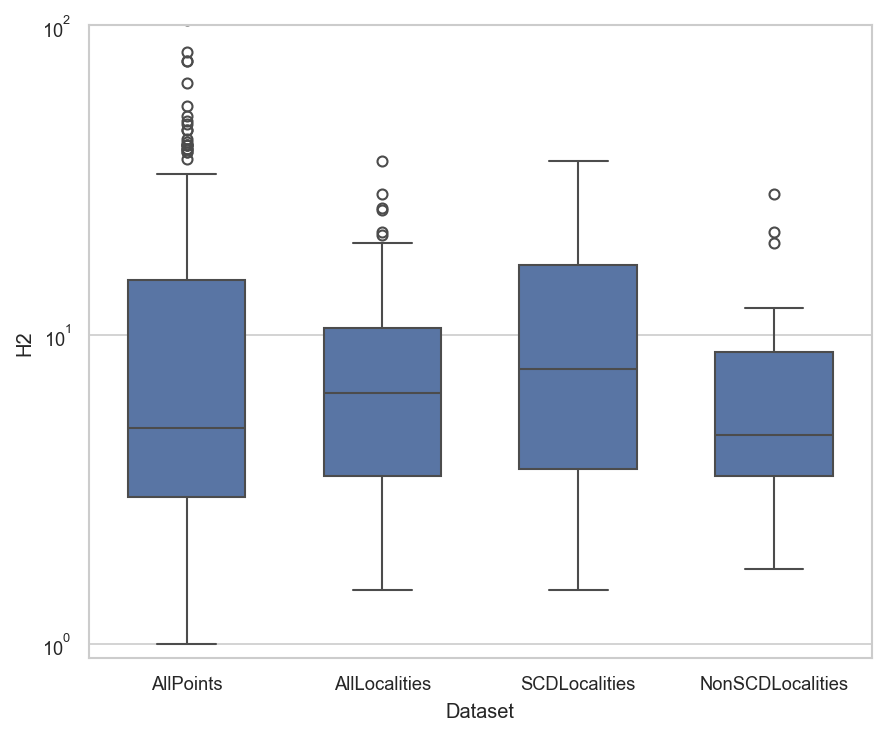

In [254]:

df_plot = pd.concat(
    {
        "AllPoints": ap,
        "AllLocalities": pd.Series(means),
        "SCDLocalities": pd.Series(ssdf_means),
        "NonSCDLocalities": pd.Series(transect_means)
    },
    names=["Dataset"]
).reset_index(level=0).rename(columns={0: "H2"})

sns.set_theme(style="whitegrid", context="paper")

fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

sns.boxplot(
    data=df_plot,
    x="Dataset",
    y="H2",
    ax=ax,
    showfliers=True,
    width=0.6
)

ax.set_ylim(0.9, 100)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

# More plotting / looking at data 

In [259]:
T_RES_COLS = ['Res 1', 'Res 2', 'Res 3 ', 'Res 4', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']
S_RES_COLS = ['Res 1', 'Res 2', 'Res 3', 'Res 4', 'Res 5', 'Res 6', 'Res 7', 'Res 8','Res 9', 'Res 10', 'Res 11', 'Res 12', 'Res 13', 'Res 14', 'Res 15']

In [277]:
transect['max'] = transect[T_RES_COLS].max(axis=1)
transect['median'] = transect[T_RES_COLS].median(axis=1)
ssdf['median'] = ssdf[S_RES_COLS].median(axis=1)

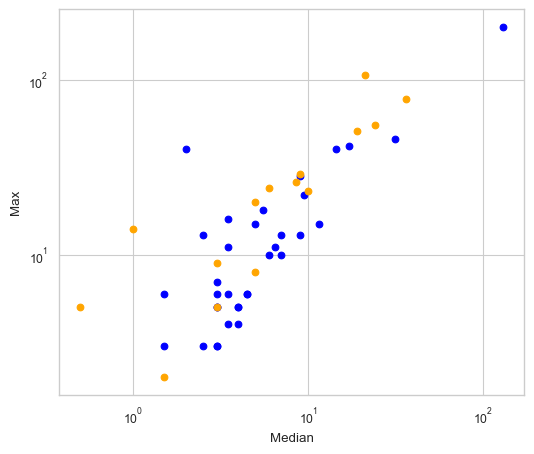

In [284]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(transect['median'], transect['max'], color='blue')
ax.scatter(ssdf['median'], ssdf['Max'], color='orange')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Max')
ax.set_xlabel('Median')
ax.set_aspect("equal")